In [53]:
import import_ipynb
import api
import matplotlib.pyplot as plt

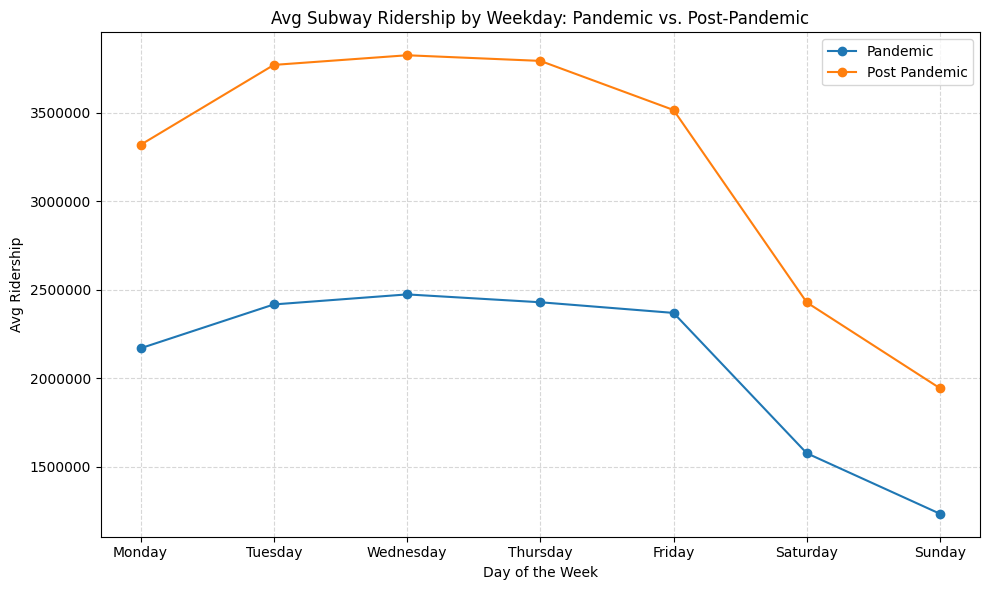

In [ ]:
# I need to understand our subway ridership during and after the pandemic
# Can we predict how ridership will be affected if we have to go through a hantavirus pandemic
# Were holidays/special events resilient in terms of subway ridership throughout the pandemic, if so, which holiday/event? 

# Compare ridership from mid pandemic and post pandemic to see if there was is a dropoff
# Compare bridge and tunnel traffic pre and post pandemic


df = api.df


pandemic_dates_mask = (df["date"] > "2020-03-12") & (df["date"] < "2023-03-06")
post_pandemic_mask = df['date'] > "2023-03-06"
df['day'] = df['date'].dt.day_name()
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 6))

ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

pandemic_data = df[pandemic_dates_mask]
post_pandemic_data = df[post_pandemic_mask]


grouped_pandemic_data = pandemic_data.groupby("day")["subways_total_estimated_ridership"].mean().reindex(week_order)
grouped_post_pandemic_data = post_pandemic_data.groupby("day")["subways_total_estimated_ridership"].mean().reindex(week_order)

grouped_pandemic_data.plot(kind="line", marker='o',ax=ax, figsize=(10, 6), label="Pandemic")
grouped_post_pandemic_data.plot(kind="line", marker='o',ax=ax, figsize=(10, 6), label="Post Pandemic")

plt.title("Avg Subway Ridership by Weekday: Pandemic vs. Post-Pandemic")
plt.xlabel("Day of the Week")
plt.ylabel("Avg Ridership")
plt.legend() 
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


